## Zadanie 1

Wykorzystując zbiór danych https://www.kaggle.com/datasets/amrahhasanov23/otodom-pl-flat-prices-in-poland dokonaj sprawdzenia poprawności danych według wytycznych:
- kompletność dla wszystkich cech,
- czy dane dla kolumny price są > 0.
- Wylicz również na tej podstawie zbiorczą metrykę jakości danych zgodnie z przykładami z wykładu.


In [3]:
import pandas as pd

df = pd.read_csv('Otodom_Flat_Listings.csv')

kompletnosc = df.notnull().mean()
print("\n1. Kompletność dla wszystkich poszczególnych cech:")
print(kompletnosc)

poprawne_ceny = df['Price'] > 0
odsetek_poprawnych_cen = poprawne_ceny.mean()
print(f"\n2. Odsetek rekordów z poprawną ceną (Price > 0): {odsetek_poprawnych_cen * 100:.2f}%")

wiersze_kompletne = df.notnull().all(axis=1)
wiersze_idealne = wiersze_kompletne & poprawne_ceny

zbiorcza_metryka = wiersze_idealne.mean()
print(f"\n3. Zbiorcza metryka jakości danych: {zbiorcza_metryka * 100:.2f}%")


1. Kompletność dla wszystkich poszczególnych cech:
Title                     1.000000
Price                     0.949056
Location                  0.999644
Surface                   1.000000
Number_of_Rooms           1.000000
Floor                     0.977200
Finishing_Condition       0.794086
Heating                   0.733880
Parking_Space             0.526541
Balcony_Garden_Terrace    0.748842
Link                      1.000000
Voivodeship               0.999644
City                      0.999644
dtype: float64

2. Odsetek rekordów z poprawną ceną (Price > 0): 94.91%

3. Zbiorcza metryka jakości danych: 27.43%


## Zadanie 2

Dla tego samego zbioru danych wyświetl histogram prezentujący cechę price, ale pomiń w tym zbiorze rekoredy, w których tej wartości brakuje.

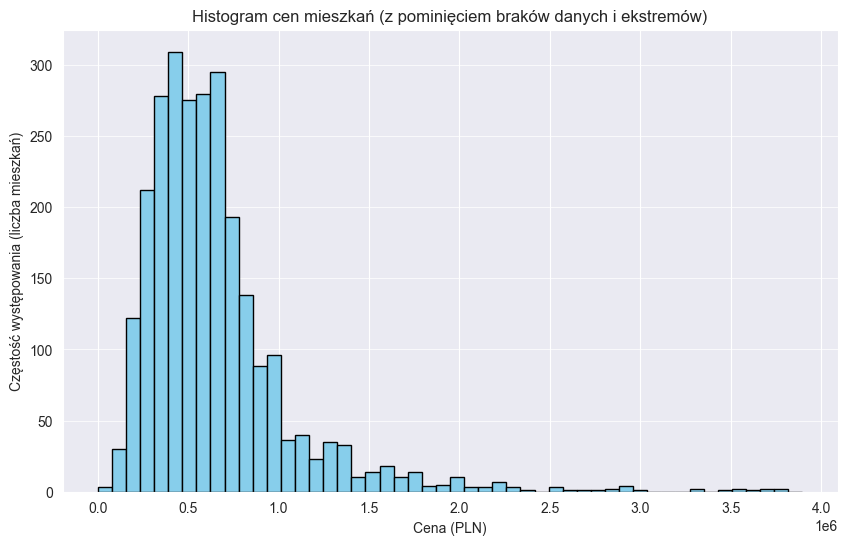

In [7]:
import matplotlib.pyplot as plt

ceny_bez_brakow = df['Price'].dropna()
gorna_granica = ceny_bez_brakow.quantile(0.98)

plt.figure(figsize=(10, 6))
plt.hist(ceny_bez_brakow, bins=50, range=(0, gorna_granica), color='skyblue', edgecolor='black')

plt.title('Histogram cen mieszkań (z pominięciem braków danych i ekstremów)')
plt.xlabel('Cena (PLN)')
plt.ylabel('Częstość występowania (liczba mieszkań)')

plt.grid(axis='y', alpha=0.75)
plt.show()

## Zadanie 3

Wyświetl wykres pudełkowy dla cechy price. Czy w danych dla tej cechy mamy widoczne wartości odstające? Jeżeli tak, to odfiltruj je ze zbioru i zapisz tę część danych (zapewne ramka pandas) do zmiennej outlier_data.

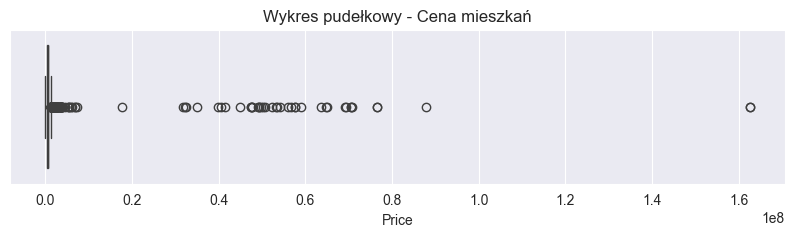


Liczba wykrytych wartości odstających: 200


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Otodom_Flat_Listings.csv')

plt.figure(figsize=(10, 2))
sns.boxplot(x=df['Price'].dropna())
plt.title("Wykres pudełkowy - Cena mieszkań")
plt.show()

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

dolna_granica = Q1 - 1.5 * IQR
gorna_granica = Q3 + 1.5 * IQR
outlier_data = df[(df['Price'] < dolna_granica) | (df['Price'] > gorna_granica)]
print(f"\nLiczba wykrytych wartości odstających: {len(outlier_data)}")

## Zadanie 4

Dodaj nową cechę do zbioru price_per_m2 i wylicz (tam gdzie to możliwe) cenę z ceceh price oraz surface. Wyświetl histogram z naniesioną linią reprezentującą wartość funkcji rozkładu dla tej cechy.

Oblicz również wartości kwartyli dla tej cechy i je wyświetl.

Czy wykres ma cechy rozkładu normalnego?

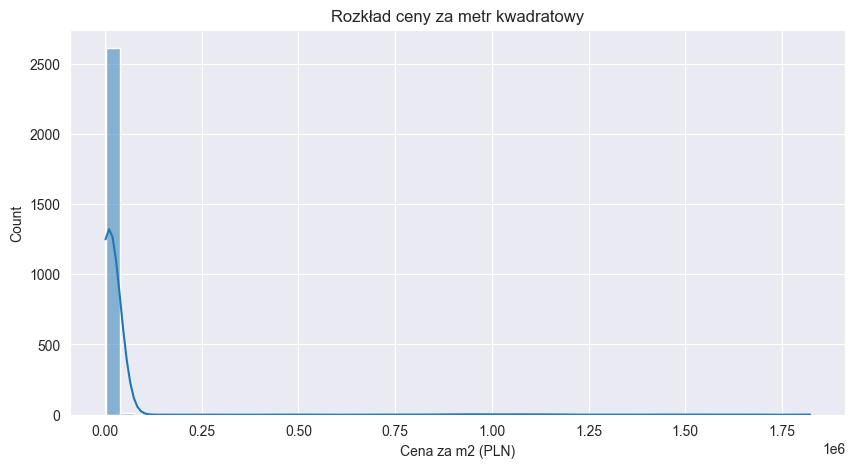

Kwartyle dla ceny za m2:
 0.25     7583.333333
0.50    10354.037664
0.75    13922.705452
Name: price_per_m2, dtype: float64


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Otodom_Flat_Listings.csv')
df['price_per_m2'] = df['Price'] / df['Surface']

plt.figure(figsize=(10, 5))
sns.histplot(df['price_per_m2'].dropna(), kde=True, bins=50)
plt.title("Rozkład ceny za metr kwadratowy")
plt.xlabel("Cena za m2 (PLN)")
plt.show()
kwartyle_m2 = df['price_per_m2'].quantile([0.25, 0.5, 0.75])
print("Kwartyle dla ceny za m2:\n", kwartyle_m2)


## Zadanie 5

Jakie jest teoretyczne (wynikające z danych rozkładu, a nie eksperymentu) prawdopodobieństwo wypadnięcia 7 orłów przy 20 rzutach uczciwą monetą? Wykorzystaj przykład z wykładu, zaprezentuj również histogram dla tego rozkładu. Oblicz i wypisz to prawdopodobieństwo.

Prawdopodobieństwo, że wypadnie dokładnie 7 orłów wynosi: 0.0739


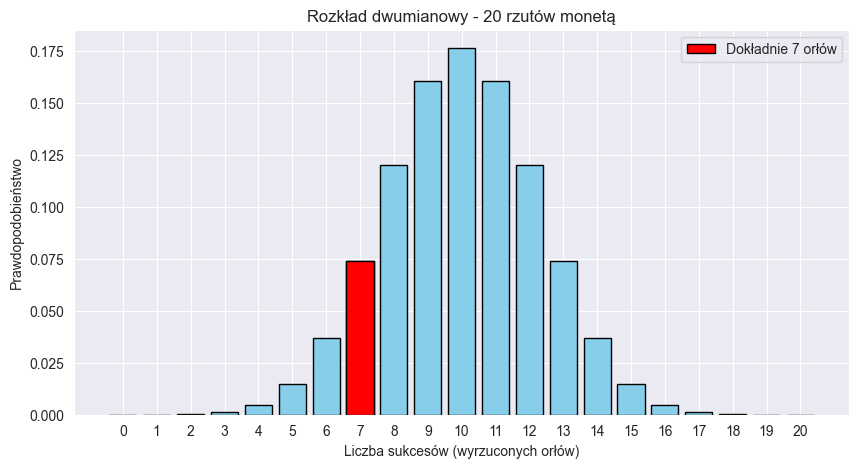

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

n = 20
p = 0.5
k = 7

prob = stats.binom.pmf(k, n, p)
print(f"Prawdopodobieństwo, że wypadnie dokładnie {k} orłów wynosi: {prob:.4f}")
x = np.arange(0, n + 1)
y = stats.binom.pmf(x, n, p)

plt.figure(figsize=(10, 5))
plt.bar(x, y, color='skyblue', edgecolor='black')

plt.bar(k, prob, color='red', edgecolor='black', label=f'Dokładnie {k} orłów')

plt.xlabel("Liczba sukcesów (wyrzuconych orłów)")
plt.ylabel("Prawdopodobieństwo")
plt.title("Rozkład dwumianowy - 20 rzutów monetą")
plt.xticks(x)
plt.legend()
plt.show()

## Zadanie 6

Napisz funkcję, która będzie wykonywała symulację rzutu sześciennymi kostkami. W funkcji możemy podać parametr określający liczbę eksperymentów oraz liczbę kostek w każdym rzucie. Funkcja zwraca listę wyników.

Wykonaj kilka symulacji z różnymi parametrami i wyświetl wyniki na wykresie typu histogram wraz z funkcją rozkładu prawdopodobieństwa.

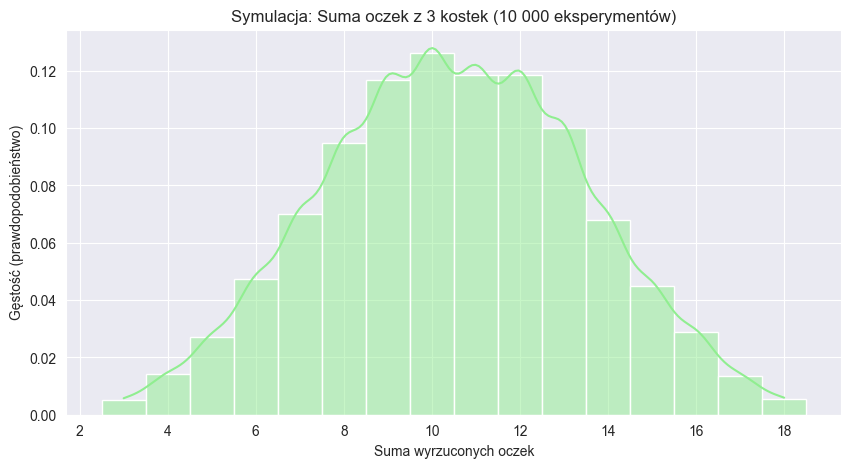

In [17]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def symulacja_rzutow(liczba_eksperymentow, liczba_kostek):
    rzuty = np.random.randint(1, 7, size=(liczba_eksperymentow, liczba_kostek))
    return rzuty.sum(axis=1)

wyniki = symulacja_rzutow(10000, 3)
plt.figure(figsize=(10, 5))
sns.histplot(wyniki, kde=True, discrete=True, stat="density", color='lightgreen')
plt.title("Symulacja: Suma oczek z 3 kostek (10 000 eksperymentów)")
plt.xlabel("Suma wyrzuconych oczek")
plt.ylabel("Gęstość (prawdopodobieństwo)")
plt.show()